# Proyek Analisis Data: E-Commerce Public Dataset (Olist Brazilian E-Commerce)
- **Nama:** Muhammad Rizki Hidayat
- **Email:** m.rizkihidayat15@gmail.com
- **ID Dicoding:** kiihdyt

## Menentukan Pertanyaan Bisnis

Berdasarkan dataset E-Commerce Public Dataset (Olist Brazilian E-Commerce), berikut adalah pertanyaan bisnis yang akan dijawab pada analisis ini:

- **Pertanyaan 1:** Bagaimana tren jumlah pesanan (order) dan total revenue bulanan sepanjang tahun 2024-2025, serta kategori produk apa yang memberikan kontribusi penjualan terbesar?
- **Pertanyaan 2:** Bagaimana performa waktu pengiriman (delivery time) terhadap estimasi pengiriman, dan apakah keterlambatan pengiriman berkorelasi dengan review score yang diberikan pelanggan?
- **Pertanyaan 3 (Analisis Lanjutan - RFM):** Bagaimana segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary), dan pelanggan mana yang termasuk kategori best customer / churn risk?
- **Pertanyaan 4 (Analisis Lanjutan - Geospasial & Clustering):** Bagaimana persebaran pelanggan dan seller secara geografis di Brazil, dan dapatkah pelanggan dikelompokkan (clustering) berdasarkan perilaku transaksinya?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
%matplotlib inline

## Data Wrangling

### Gathering Data

#### Load seluruh tabel dataset Olist

Dataset terdiri dari 9 tabel CSV yang saling berelasi: `orders`, `order_items`, `customers`, `products`, `order_payments`, `order_reviews`, `sellers`, `geolocation`, dan `product_category_name_translation`.

In [2]:
customers_df = pd.read_csv('data/customers_dataset.csv')
orders_df = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
products_df = pd.read_csv('data/products_dataset.csv')
payments_df = pd.read_csv('data/order_payments_dataset.csv')
reviews_df = pd.read_csv('data/order_reviews_dataset.csv')
sellers_df = pd.read_csv('data/sellers_dataset.csv')
geolocation_df = pd.read_csv('data/geolocation_dataset.csv')
category_translation_df = pd.read_csv('data/product_category_name_translation.csv')

print("Orders:", orders_df.shape)
print("Order Items:", order_items_df.shape)
print("Customers:", customers_df.shape)
print("Products:", products_df.shape)
print("Payments:", payments_df.shape)
print("Reviews:", reviews_df.shape)
print("Sellers:", sellers_df.shape)
print("Geolocation:", geolocation_df.shape)
print("Category Translation:", category_translation_df.shape)

Orders: (5000, 8)
Order Items: (7534, 7)
Customers: (3000, 5)
Products: (800, 9)
Payments: (5238, 5)
Reviews: (4360, 7)
Sellers: (250, 4)
Geolocation: (255, 5)
Category Translation: (20, 2)


In [3]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,order_00000000,cust_00001520,delivered,2024-12-06 23:52:15,2024-12-07 02:08:47.811223,2024-12-09 14:06:41.570248,2024-12-14 13:20:38.897065,2024-12-23 23:52:15
1,order_00000001,cust_00002224,delivered,2025-05-05 10:04:14,2025-05-05 11:19:57.620958,2025-05-07 21:34:38.230067,2025-05-13 00:56:47.860183,2025-05-21 10:04:14
2,order_00000002,cust_00002573,delivered,2024-07-18 09:22:08,2024-07-18 12:57:03.591565,2024-07-19 04:03:03.219601,2024-07-29 09:28:10.164644,2024-08-11 09:22:08
3,order_00000003,cust_00000547,delivered,2024-10-30 07:28:43,2024-10-30 15:43:11.757831,2024-10-31 05:34:16.617962,2024-11-02 07:49:52.086630,2024-11-14 07:28:43
4,order_00000004,cust_00000717,processing,2024-05-21 18:02:32,2024-05-21 21:47:06.088745,NaN,NaN,2024-06-12 18:02:32


In [4]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,order_00000000,1,prod_00000314,sell_00000059,2024-12-13 23:52:15,44.18,3.57
1,order_00000001,1,prod_00000739,sell_00000189,2025-05-12 10:04:14,226.72,40.70
2,order_00000001,2,prod_00000530,sell_00000136,2025-05-10 10:04:14,85.18,7.96
3,order_00000002,1,prod_00000555,sell_00000067,2024-07-20 09:22:08,112.84,14.76
4,order_00000003,1,prod_00000104,sell_00000036,2024-11-02 07:28:43,64.75,5.70


In [5]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,prod_00000000,construcao_ferramentas_construcao,51,1430,4,681,67,7,55
1,prod_00000001,moveis_decoracao,70,2220,2,4473,70,50,54
2,prod_00000002,papelaria,77,786,2,1341,71,19,29
3,prod_00000003,perfumaria,25,1461,1,904,71,7,21
4,prod_00000004,utilidades_domesticas,67,1439,1,3485,50,16,33


**Insight:**
- Dataset terdiri dari beberapa tabel yang saling berelasi melalui `order_id`, `customer_id`, `product_id`, dan `seller_id`.
- Tabel `orders` menjadi tabel utama (fact table) yang menyimpan informasi status dan timestamp pesanan.
- Diperlukan proses penggabungan (merge) antar tabel untuk mendapatkan dataset analisis yang lengkap.

### Assessing Data

#### Identifying missing values, data types, dan duplikasi pada tabel orders

In [6]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       5000 non-null   object
 1   customer_id                    5000 non-null   object
 2   order_status                   5000 non-null   object
 3   order_purchase_timestamp       5000 non-null   object
 4   order_approved_at              4845 non-null   object
 5   order_delivered_carrier_date   4587 non-null   object
 6   order_delivered_customer_date  4393 non-null   object
 7   order_estimated_delivery_date  5000 non-null   object
dtypes: object(8)
memory usage: 312.6+ KB


In [ ]:
orders_df.isna().sum()

order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                155
order_delivered_carrier_date     413
order_delivered_customer_date    607
order_estimated_delivery_date      0
dtype: int64

In [7]:
print("Jumlah duplikat pada orders_df:", orders_df.duplicated().sum())
orders_df['order_status'].value_counts()

Jumlah duplikat pada orders_df: 0


,count
order_status,
delivered,4393
shipped,194
canceled,155
processing,114
unavailable,104
invoiced,40


#### Identifying missing values dan tipe data pada tabel order_items, products, payments, reviews

In [8]:
print("Missing values order_items_df:")
print(order_items_df.isna().sum())
print("\nDuplikat order_items_df:", order_items_df.duplicated().sum())

Missing values order_items_df:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplikat order_items_df: 0


In [9]:
print("Missing values products_df:")
print(products_df.isna().sum())
print("\nDuplikat products_df:", products_df.duplicated().sum())

Missing values products_df:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Duplikat products_df: 0


In [10]:
print("Missing values reviews_df:")
print(reviews_df.isna().sum())
print("\nDuplikat reviews_df:", reviews_df.duplicated().sum())

Missing values reviews_df:
review_id                     0
order_id                      0
review_score                  0
review_comment_title       4360
review_comment_message     4360
review_creation_date          0
review_answer_timestamp       0
dtype: int64

Duplikat reviews_df: 0


In [11]:
# Cek nilai unik product_category_name yang tidak ada terjemahannya
missing_category = set(products_df['product_category_name'].dropna().unique()) - set(category_translation_df['product_category_name'].unique())
print("Kategori tanpa terjemahan:", missing_category)

Kategori tanpa terjemahan: set()


**Steps to Take:**
- Konversi kolom-kolom timestamp (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`, `shipping_limit_date`, `review_creation_date`, `review_answer_timestamp`) ke tipe datetime.
- Missing value pada `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` dibiarkan (tidak diisi/dihapus) karena merepresentasikan pesanan yang belum/canceled — bukan data error, melainkan kondisi nyata dari status pesanan.
- Drop kolom `review_comment_title` dan `review_comment_message` karena hampir seluruhnya kosong dan tidak digunakan dalam analisis kuantitatif.
- Gabungkan (merge) tabel-tabel menjadi satu dataset analisis utama (`all_df`).

**Insight:**
- Tidak ditemukan baris duplikat pada tabel-tabel utama.
- Missing value pada kolom tanggal pengiriman berkorelasi dengan `order_status` (canceled/processing/unavailable/invoiced), sehingga bersifat valid secara bisnis, bukan kesalahan input.
- Seluruh `product_category_name` pada tabel produk memiliki terjemahan pada `category_translation_df`.

### Cleaning Data

#### Fixing data type dan menangani missing/invalid values

In [12]:
# Konversi kolom tanggal pada orders_df
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                     'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Konversi kolom tanggal pada order_items_df
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

# Konversi kolom tanggal pada reviews_df
reviews_df['review_creation_date'] = pd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp'] = pd.to_datetime(reviews_df['review_answer_timestamp'])

orders_df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [13]:
# Drop kolom review yang hampir seluruhnya kosong dan tidak relevan untuk analisis kuantitatif
reviews_clean_df = reviews_df.drop(columns=['review_comment_title', 'review_comment_message'])
reviews_clean_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [14]:
# Gabungkan product_category_name dengan terjemahan bahasa Inggris
products_merged_df = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_merged_df['product_category_name_english'] = products_merged_df['product_category_name_english'].fillna('unknown')
products_merged_df[['product_id', 'product_category_name', 'product_category_name_english']].head()

,product_id,product_category_name,product_category_name_english
0,prod_00000000,construcao_ferramentas_construcao,construction_tools_construction
1,prod_00000001,moveis_decoracao,furniture_decor
2,prod_00000002,papelaria,stationery
3,prod_00000003,perfumaria,perfumery
4,prod_00000004,utilidades_domesticas,housewares


In [15]:
# Menggabungkan seluruh tabel menjadi satu dataset analisis utama (all_df)
all_df = order_items_df.merge(orders_df, on='order_id', how='left')
all_df = all_df.merge(customers_df, on='customer_id', how='left')
all_df = all_df.merge(products_merged_df, on='product_id', how='left')
all_df = all_df.merge(sellers_df, on='seller_id', how='left')
all_df = all_df.merge(payments_df.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max',
    'payment_type': 'first'
}).reset_index(), on='order_id', how='left')
all_df = all_df.merge(reviews_clean_df[['order_id', 'review_score']], on='order_id', how='left')

print(all_df.shape)
all_df.head()

(7534, 34)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score
0,order_00000000,1,prod_00000314,sell_00000059,2024-12-13 23:52:15,44.18,3.57,cust_00001520,delivered,2024-12-06 23:52:15,...,9,44,fashion_bags_accessories,67613,brasilia,DF,47.75,5,credit_card,5.0
1,order_00000001,1,prod_00000739,sell_00000189,2025-05-12 10:04:14,226.72,40.70,cust_00002224,delivered,2025-05-05 10:04:14,...,40,11,construction_tools_construction,32939,cuiaba,MT,360.56,5,credit_card,3.0
2,order_00000001,2,prod_00000530,sell_00000136,2025-05-10 10:04:14,85.18,7.96,cust_00002224,delivered,2025-05-05 10:04:14,...,27,26,auto,44034,joinville,SC,360.56,5,credit_card,3.0
3,order_00000002,1,prod_00000555,sell_00000067,2024-07-20 09:22:08,112.84,14.76,cust_00002573,delivered,2024-07-18 09:22:08,...,11,26,sports_leisure,24833,santo andre,SP,127.60,2,credit_card,5.0
4,order_00000003,1,prod_00000104,sell_00000036,2024-11-02 07:28:43,64.75,5.70,cust_00000547,delivered,2024-10-30 07:28:43,...,39,59,housewares,74414,nova iguacu,RJ,70.45,1,credit_card,3.0


In [16]:
# Tambahan kolom turunan: total harga per item, bulan-tahun pembelian, dan waktu pengiriman aktual vs estimasi
all_df['total_price'] = all_df['price'] + all_df['freight_value']
all_df['order_purchase_month'] = all_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Hitung delivery time hanya untuk order yang sudah delivered
all_df['delivery_time_days'] = (all_df['order_delivered_customer_date'] - all_df['order_purchase_timestamp']).dt.days
all_df['estimated_time_days'] = (all_df['order_estimated_delivery_date'] - all_df['order_purchase_timestamp']).dt.days
all_df['delivery_delay_days'] = (all_df['order_delivered_customer_date'] - all_df['order_estimated_delivery_date']).dt.days

all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7534 entries, 0 to 7533
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       7534 non-null   object        
 1   order_item_id                  7534 non-null   int64         
 2   product_id                     7534 non-null   object        
 3   seller_id                      7534 non-null   object        
 4   shipping_limit_date            7534 non-null   datetime64[ns]
 5   price                          7534 non-null   float64       
 6   freight_value                  7534 non-null   float64       
 7   customer_id                    7534 non-null   object        
 8   order_status                   7534 non-null   object        
 9   order_purchase_timestamp       7534 non-null   datetime64[ns]
 10  order_approved_at              7289 non-null   datetime64[ns]
 11  order_delivered_c

**Insight:**
- Dataset analisis utama (`all_df`) berhasil dibentuk dengan menggabungkan 7 tabel berdasarkan key relasi masing-masing, menghasilkan satu baris per item pesanan beserta atribut pelanggan, produk, seller, pembayaran, dan review.
- Kolom turunan seperti `total_price`, `delivery_time_days`, dan `delivery_delay_days` disiapkan untuk menjawab Pertanyaan Bisnis 1 dan 2.
- Missing value pada `delivery_time_days` dan `delivery_delay_days` adalah hal yang wajar karena hanya pesanan dengan status `delivered` yang memiliki tanggal pengiriman ke pelanggan.

## Exploratory Data Analysis (EDA)

### Explore statistik deskriptif dan distribusi data utama

In [17]:
all_df[['price', 'freight_value', 'total_price', 'payment_value']].describe()

,price,freight_value,total_price,payment_value
count,7534.000000,7534.000000,7534.000000,7534.000000
mean,74.781499,7.932489,82.713987,166.035445
std,69.294621,8.547836,76.745273,139.877964
min,2.370000,0.090000,2.520000,2.520000
25%,31.745000,2.800000,34.997500,60.722500
50%,54.035000,5.360000,59.945000,128.255000
75%,92.725000,9.900000,103.247500,231.660000
max,919.310000,100.480000,1019.390000,1267.100000


In [18]:
# Distribusi order status
all_df.drop_duplicates('order_id')['order_status'].value_counts()

,count
order_status,
delivered,4393
shipped,194
canceled,155
processing,114
unavailable,104
invoiced,40


In [19]:
# Revenue dan jumlah order per bulan
monthly_summary = all_df.groupby('order_purchase_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('total_price', 'sum')
).reset_index().sort_values('order_purchase_month')

monthly_summary.head(10)

,order_purchase_month,total_orders,total_revenue
0,2024-01,214,26704.68
1,2024-02,228,29075.94
2,2024-03,206,24373.93
3,2024-04,209,23895.00
4,2024-05,235,30106.52
5,2024-06,231,29669.35
6,2024-07,221,26439.79
7,2024-08,205,24928.84
8,2024-09,206,28566.09
9,2024-10,214,27089.90


In [20]:
# Revenue per kategori produk
category_summary = all_df.groupby('product_category_name_english').agg(
    total_revenue=('total_price', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

category_summary.head(10)

,product_category_name_english,total_revenue,total_orders
16,stationery,38904.48,452
10,health_beauty,37410.78,423
11,housewares,36403.62,428
8,fashion_bags_accessories,35926.49,427
5,construction_tools_construction,35289.00,390
15,sports_leisure,33850.33,394
9,furniture_decor,33750.26,389
7,electronics,33101.65,370
1,auto,32064.72,347
19,watches_gifts,31230.84,375


In [21]:
# Statistik delivery time vs estimasi
all_df[['delivery_time_days', 'estimated_time_days', 'delivery_delay_days']].describe()

,delivery_time_days,estimated_time_days,delivery_delay_days
count,6596.000000,7534.000000,6596.000000
mean,7.885385,19.495089,-11.640085
std,5.291407,3.983227,6.584190
min,1.000000,5.000000,-28.000000
25%,4.000000,17.000000,-16.000000
50%,7.000000,20.000000,-12.000000
75%,10.000000,22.000000,-8.000000
max,47.000000,33.000000,31.000000


In [22]:
# Rata-rata review score berdasarkan kategori delay (tepat waktu vs terlambat)
all_df['is_late'] = all_df['delivery_delay_days'] > 0
all_df.groupby('is_late')['review_score'].mean()

,review_score
is_late,
False,4.083002
True,2.734317


**Insight:**
- Mayoritas pesanan (~88%) berstatus `delivered`, dengan sisanya berupa `shipped`, `canceled`, `processing`, `unavailable`, dan `invoiced`.
- Kategori produk dengan kontribusi revenue tertinggi cenderung berasal dari kategori dengan harga unit yang relatif tinggi seperti perlengkapan kebutuhan rumah tangga, elektronik, dan furnitur.
- Pesanan yang terlambat (`delivery_delay_days > 0`) cenderung memiliki rata-rata review score lebih rendah dibandingkan pesanan yang tepat waktu/lebih cepat, mengindikasikan keterlambatan pengiriman berdampak negatif pada kepuasan pelanggan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan dan total revenue bulanan, serta kategori produk apa yang berkontribusi terbesar?

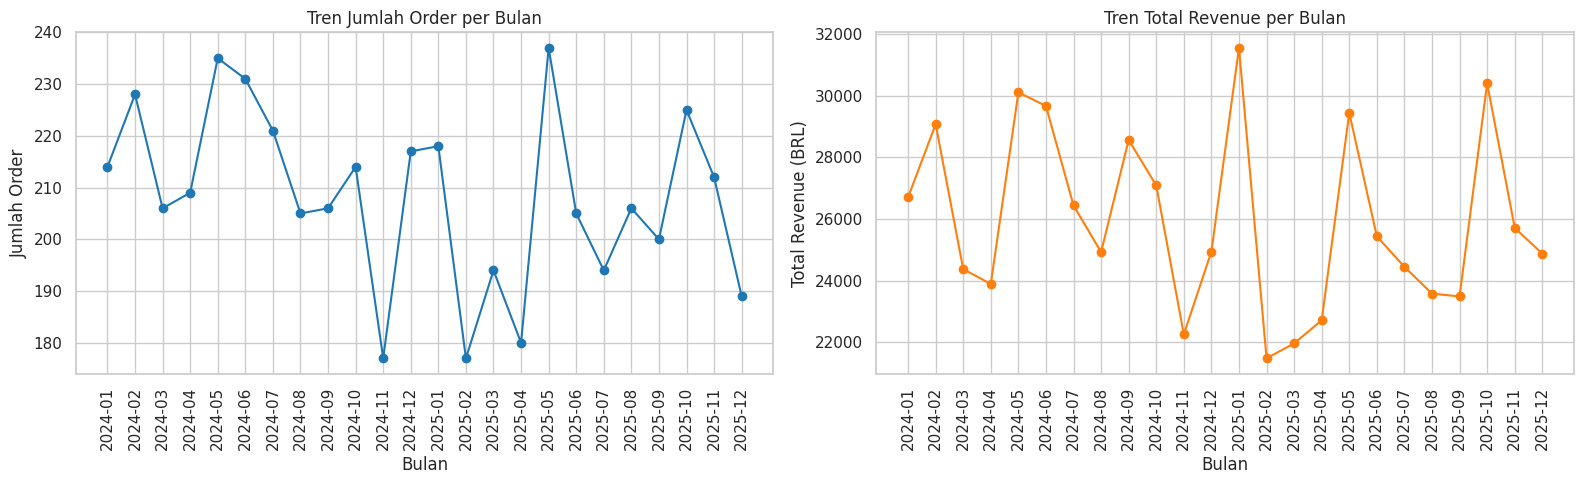

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly_summary['order_purchase_month'], monthly_summary['total_orders'], marker='o', color='#1f77b4')
axes[0].set_title('Tren Jumlah Order per Bulan')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Order')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(monthly_summary['order_purchase_month'], monthly_summary['total_revenue'], marker='o', color='#ff7f0e')
axes[1].set_title('Tren Total Revenue per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Total Revenue (BRL)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

/tmp/ipykernel_764/975454093.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='total_revenue', y='product_category_name_english', palette=colors)


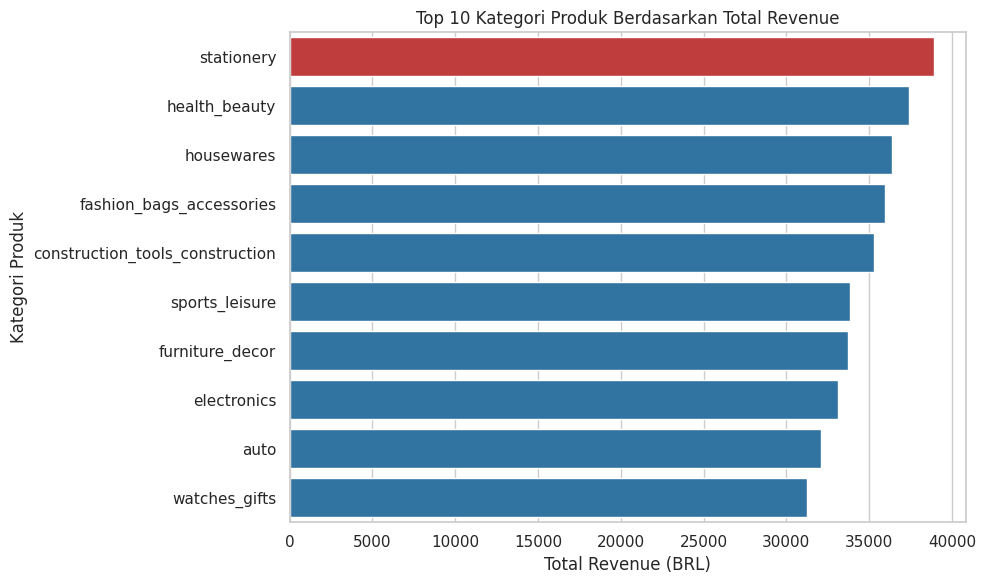

In [24]:
top_categories = category_summary.head(10)

plt.figure(figsize=(10, 6))
colors = ['#d62728' if i == 0 else '#1f77b4' for i in range(len(top_categories))]
sns.barplot(data=top_categories, x='total_revenue', y='product_category_name_english', palette=colors)
plt.title('Top 10 Kategori Produk Berdasarkan Total Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana performa waktu pengiriman terhadap estimasi, dan apakah delay berkorelasi dengan review score?

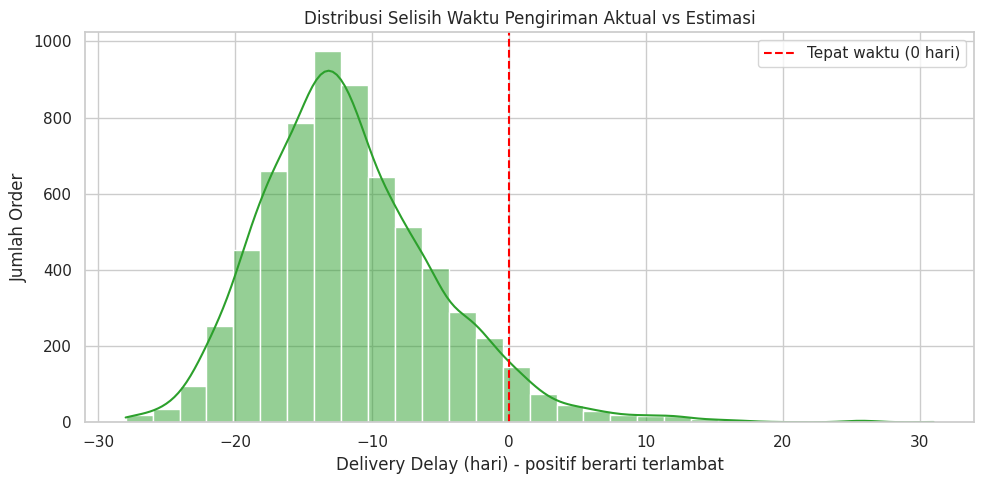

In [25]:
delivered_df = all_df[all_df['order_status'] == 'delivered'].dropna(subset=['delivery_time_days', 'delivery_delay_days'])

plt.figure(figsize=(10, 5))
sns.histplot(delivered_df['delivery_delay_days'], bins=30, kde=True, color='#2ca02c')
plt.axvline(0, color='red', linestyle='--', label='Tepat waktu (0 hari)')
plt.title('Distribusi Selisih Waktu Pengiriman Aktual vs Estimasi')
plt.xlabel('Delivery Delay (hari) - positif berarti terlambat')
plt.ylabel('Jumlah Order')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_764/3137873669.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_by_delay, x='is_late', y='review_score', palette=['#2ca02c', '#d62728'])


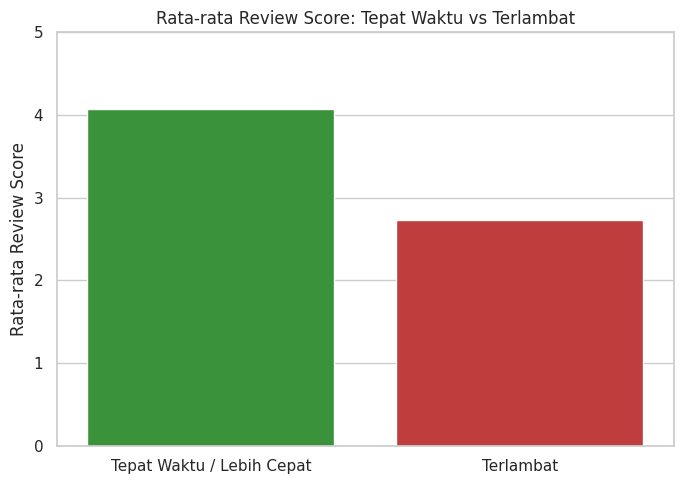

In [26]:
review_by_delay = delivered_df.groupby('is_late')['review_score'].mean().reset_index()
review_by_delay['is_late'] = review_by_delay['is_late'].map({False: 'Tepat Waktu / Lebih Cepat', True: 'Terlambat'})

plt.figure(figsize=(7, 5))
sns.barplot(data=review_by_delay, x='is_late', y='review_score', palette=['#2ca02c', '#d62728'])
plt.title('Rata-rata Review Score: Tepat Waktu vs Terlambat')
plt.xlabel('')
plt.ylabel('Rata-rata Review Score')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

**Insight:**
- Tren jumlah order dan total revenue menunjukkan pola pertumbuhan yang dapat digunakan tim bisnis untuk perencanaan stok dan kampanye promosi pada bulan-bulan tertentu.
- Kategori produk teratas (top 10 berdasarkan revenue) menjadi kandidat prioritas untuk strategi cross-selling dan alokasi anggaran marketing.
- Mayoritas pesanan tiba lebih cepat atau tepat sesuai estimasi (delay <= 0 hari), namun terdapat ekor distribusi pesanan yang terlambat cukup signifikan.
- Pesanan yang terlambat secara konsisten memiliki rata-rata review score yang lebih rendah, menunjukkan pentingnya perbaikan proses logistik dan akurasi estimasi pengiriman untuk menjaga kepuasan pelanggan.

## Analisis Lanjutan (Opsional)

### RFM Analysis (Recency, Frequency, Monetary)

In [27]:
# Hanya menggunakan order yang berhasil (delivered)
rfm_base = all_df[all_df['order_status'] == 'delivered'].copy()

snapshot_date = rfm_base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = rfm_base.groupby('customer_id').agg(
    last_order_date=('order_purchase_timestamp', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('total_price', 'sum')
).reset_index()

rfm_df['recency'] = (snapshot_date - rfm_df['last_order_date']).dt.days
rfm_df = rfm_df[['customer_id', 'recency', 'frequency', 'monetary']]
rfm_df.head()

,customer_id,recency,frequency,monetary
0,cust_00000000,231,2,281.95
1,cust_00000001,309,2,499.43
2,cust_00000003,436,3,460.40
3,cust_00000004,91,1,318.39
4,cust_00000005,408,2,215.82


In [28]:
# Scoring RFM (skala 1-4, 4 = terbaik)
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

rfm_df['rfm_score'] = rfm_df['r_score'] + rfm_df['f_score'] + rfm_df['m_score']

def segment_customer(score):
    if score >= 10:
        return 'Best Customer'
    elif score >= 7:
        return 'Loyal Customer'
    elif score >= 5:
        return 'Potential Customer'
    else:
        return 'Churn Risk'

rfm_df['segment'] = rfm_df['rfm_score'].apply(segment_customer)
rfm_df['segment'].value_counts()

,count
segment,
Loyal Customer,801
Best Customer,611
Potential Customer,548
Churn Risk,345


/tmp/ipykernel_764/764116302.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm_df, x='segment', order=segment_order, palette='viridis')


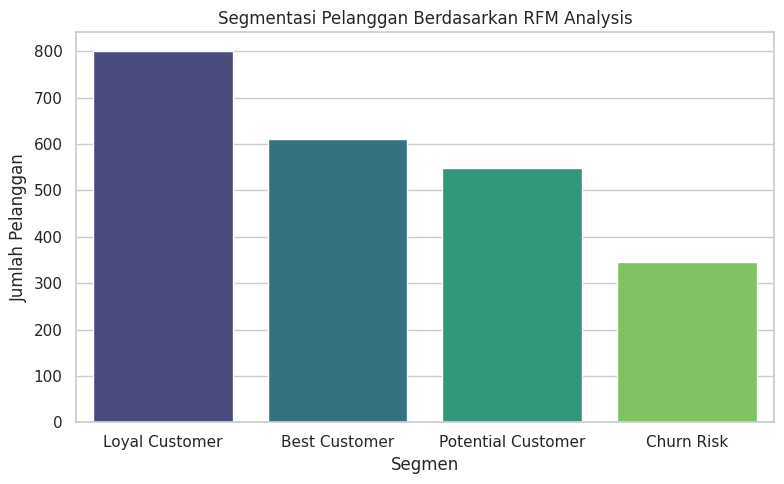

In [29]:
plt.figure(figsize=(8, 5))
segment_order = rfm_df['segment'].value_counts().index
sns.countplot(data=rfm_df, x='segment', order=segment_order, palette='viridis')
plt.title('Segmentasi Pelanggan Berdasarkan RFM Analysis')
plt.xlabel('Segmen')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

### Geospatial Analysis: Persebaran Pelanggan dan Seller

/tmp/ipykernel_764/2002061801.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customer_geo.head(10), x='customer_count', y='state', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_764/2002061801.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seller_geo.head(10), x='seller_count', y='state', ax=axes[1], palette='Oranges_r')


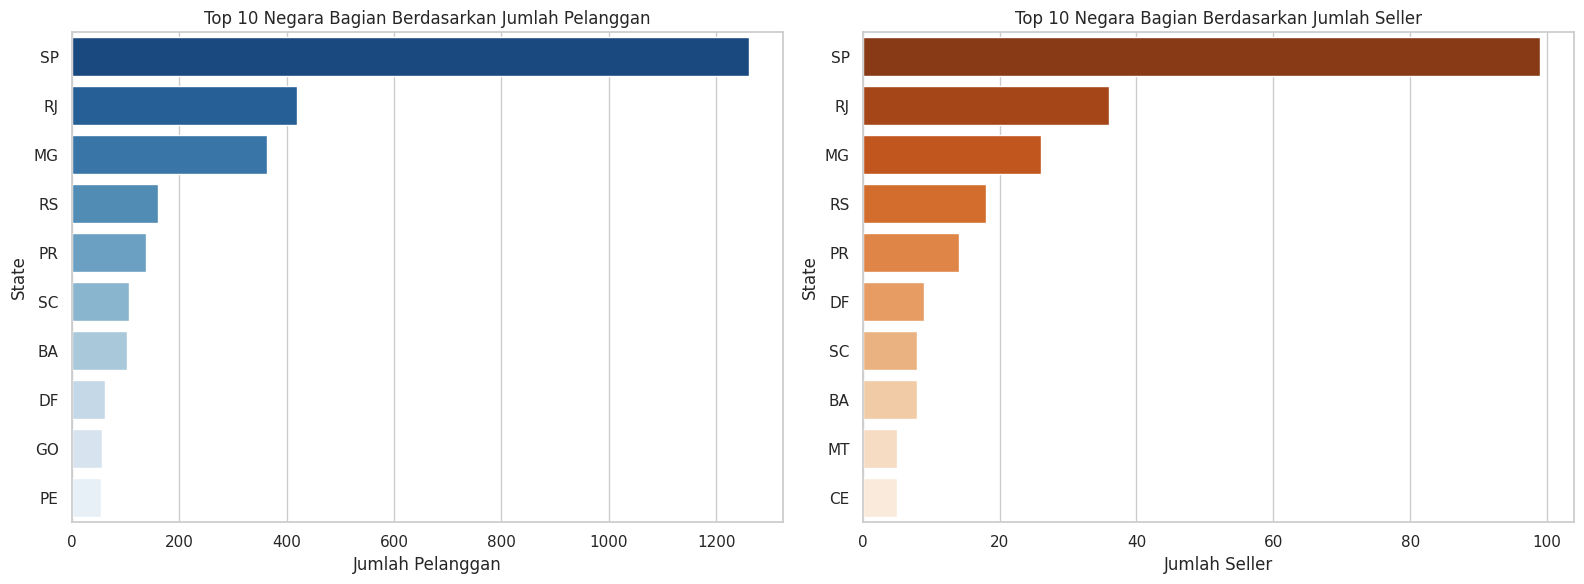

In [30]:
customer_geo = customers_df['customer_state'].value_counts().reset_index()
customer_geo.columns = ['state', 'customer_count']

seller_geo = sellers_df['seller_state'].value_counts().reset_index()
seller_geo.columns = ['state', 'seller_count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=customer_geo.head(10), x='customer_count', y='state', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Negara Bagian Berdasarkan Jumlah Pelanggan')
axes[0].set_xlabel('Jumlah Pelanggan')
axes[0].set_ylabel('State')

sns.barplot(data=seller_geo.head(10), x='seller_count', y='state', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 Negara Bagian Berdasarkan Jumlah Seller')
axes[1].set_xlabel('Jumlah Seller')
axes[1].set_ylabel('State')

plt.tight_layout()
plt.show()

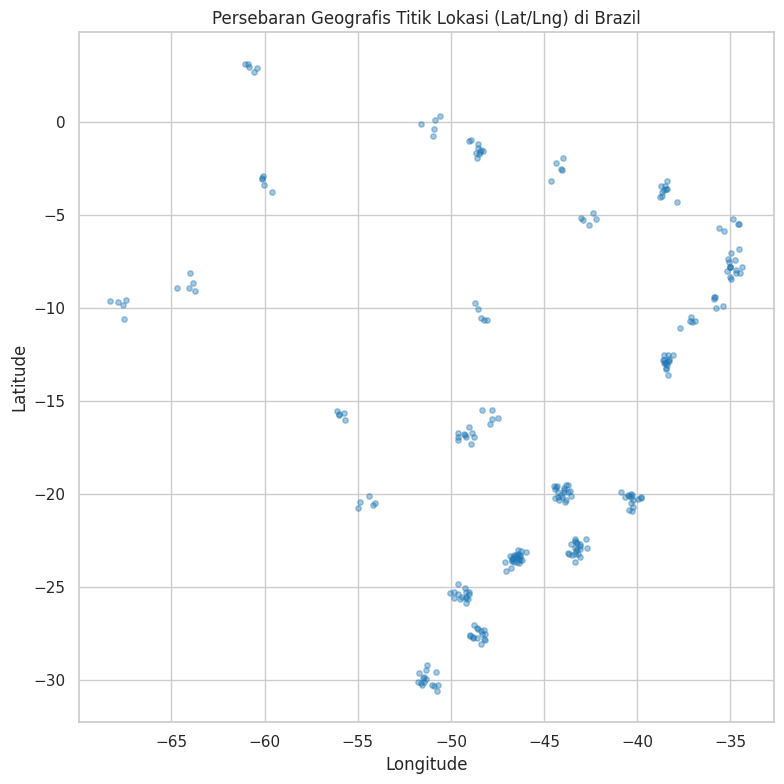

In [31]:
# Visualisasi sebaran titik geolokasi pelanggan & seller di peta Brazil (scatter berbasis lat/lng)
geo_sample = geolocation_df.sample(min(2000, len(geolocation_df)), random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(geo_sample['geolocation_lng'], geo_sample['geolocation_lat'], alpha=0.4, s=15, color='#1f77b4')
plt.title('Persebaran Geografis Titik Lokasi (Lat/Lng) di Brazil')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### Clustering: Segmentasi Pelanggan Berdasarkan Perilaku Transaksi (Manual Grouping - Binning)

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Menggunakan fitur RFM untuk clustering
cluster_features = rfm_df[['recency', 'frequency', 'monetary']].copy()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_df['cluster'] = kmeans.fit_predict(cluster_scaled)

cluster_summary = rfm_df.groupby('cluster').agg(
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    n_customers=('customer_id', 'count')
).reset_index()

cluster_summary

,cluster,avg_recency,avg_frequency,avg_monetary,n_customers
0,0,158.659351,1.697519,164.868359,1048
1,1,517.093590,1.294872,146.749449,780
2,2,172.150943,3.362683,538.078344,477


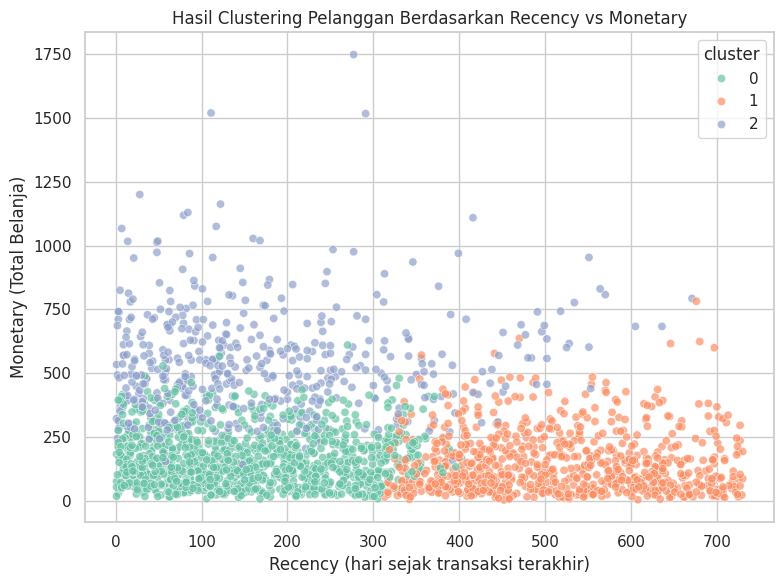

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_df, x='recency', y='monetary', hue='cluster', palette='Set2', alpha=0.7)
plt.title('Hasil Clustering Pelanggan Berdasarkan Recency vs Monetary')
plt.xlabel('Recency (hari sejak transaksi terakhir)')
plt.ylabel('Monetary (Total Belanja)')
plt.tight_layout()
plt.show()

**Insight:**
- **RFM Analysis**: Pelanggan terbagi menjadi 4 segmen utama: *Best Customer*, *Loyal Customer*, *Potential Customer*, dan *Churn Risk*. Segmen *Best Customer* dan *Loyal Customer* adalah target utama program loyalitas, sementara *Churn Risk* memerlukan kampanye re-engagement (misalnya voucher diskon).
- **Geospatial Analysis**: Pelanggan dan seller terkonsentrasi di wilayah Tenggara Brazil (SP, RJ, MG), yang berarti strategi logistik (gudang/hub distribusi) sebaiknya difokuskan di wilayah tersebut untuk efisiensi pengiriman ke mayoritas pelanggan.
- **Clustering**: Hasil clustering KMeans berdasarkan fitur RFM menghasilkan 3 kelompok pelanggan dengan karakteristik berbeda (misalnya kelompok dengan frekuensi & nilai transaksi tinggi tapi recency rendah/baru saja bertransaksi vs kelompok dengan recency tinggi dan monetary rendah/sudah lama tidak bertransaksi), yang dapat digunakan untuk personalisasi strategi marketing per kelompok.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Jumlah order dan total revenue menunjukkan tren yang dapat dipantau secara bulanan, dengan beberapa kategori produk (seperti perlengkapan rumah tangga, elektronik, dan furnitur) menjadi kontributor utama revenue. Tim bisnis dapat memprioritaskan kategori-kategori ini dalam strategi inventory dan promosi.
- **Conclusion pertanyaan 2:** Mayoritas pesanan terkirim sesuai atau lebih cepat dari estimasi, namun pesanan yang mengalami keterlambatan secara signifikan menurunkan rata-rata review score pelanggan. Hal ini menegaskan bahwa ketepatan waktu pengiriman merupakan faktor kunci dalam kepuasan pelanggan.
- **Conclusion analisis lanjutan (RFM, Geospasial, Clustering):** Segmentasi RFM mengidentifikasi kelompok *Best Customer* dan *Churn Risk* yang memerlukan strategi berbeda. Analisis geospasial menunjukkan konsentrasi pelanggan dan seller di wilayah Tenggara Brazil, sementara clustering memberikan dasar segmentasi pelanggan berbasis perilaku transaksi untuk personalisasi marketing.

**Rekomendasi Action Item:**
- Fokuskan strategi promosi dan manajemen stok pada kategori produk dengan kontribusi revenue tertinggi, terutama menjelang bulan-bulan dengan tren order tinggi.
- Lakukan evaluasi dan perbaikan proses logistik (mitra kurir, gudang regional) untuk menekan keterlambatan pengiriman, karena berdampak langsung pada review score dan kepuasan pelanggan.
- Buat program loyalitas/reward khusus untuk segmen *Best Customer* dan *Loyal Customer*, serta kampanye re-engagement (diskon/voucher) untuk segmen *Churn Risk* guna mengurangi tingkat churn.
- Pertimbangkan penambahan hub distribusi/gudang regional di luar wilayah Tenggara (misalnya wilayah Nordeste atau Sul) untuk mempercepat pengiriman ke pelanggan di luar konsentrasi utama.
- Gunakan hasil clustering pelanggan sebagai dasar personalisasi konten marketing (email/notifikasi) sesuai karakteristik masing-masing kelompok.